In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


### 1. Loading the California Housing Dataset from scikit-learn
We will use scikit-learn's built-in `fetch_california_housing` dataset. This dataset contains 20,640 census block groups in California, with features describing the demographics and houses in those blocks, and the target variable is the median house value.

**Features in the dataset:**
- `MedInc`: Median income in block group (expressed in tens of thousands of dollars, e.g., 8.3 = $83,000)
- `HouseAge`: Median house age in block group
- `AveRooms`: Average number of rooms per household
- `AveBedrms`: Average number of bedrooms per household
- `Population`: Block group population
- `AveOccup`: Average number of household members
- `Latitude`: Block group latitude
- `Longitude`: Block group longitude

**Target:**
- `MedHouseVal` (Median house value, expressed in hundreds of thousands of dollars, e.g., 2.0 = $200,000)

In [2]:
from sklearn.datasets import fetch_california_housing

# Load California Housing Dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

# Display basic information and shape
print(f"Dataset Shape: {df.shape}")
print("\nFeature names:")
print(list(california.feature_names))
print("\nFirst 5 rows of the California Housing dataset:")
df.head()

Dataset Shape: (20640, 9)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows of the California Housing dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 2. Exploratory Data Analysis (EDA)
Let's explore the dataset by plotting:
1. A correlation heatmap of the features and the target variable (`MedHouseVal`).
2. A scatter plot of `MedInc` (Median Income) vs. `MedHouseVal` (Target) since income is usually the strongest predictor of house prices.

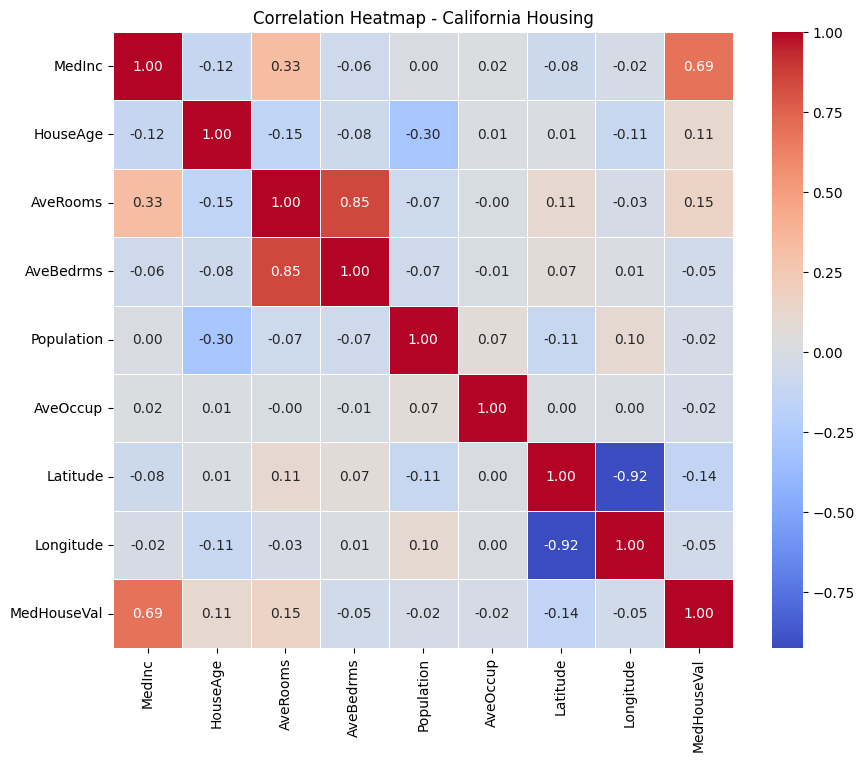

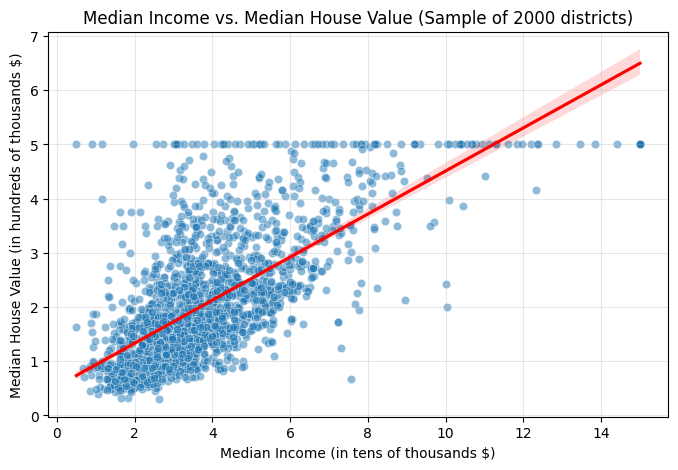

In [3]:
# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - California Housing')
plt.show()

# 2. Scatter Plot: MedInc vs MedHouseVal
# We sample 2000 rows to prevent over-plotting and keep the plot clean
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.sample(2000, random_state=42), x='MedInc', y='MedHouseVal', alpha=0.5)
sns.regplot(data=df.sample(2000, random_state=42), x='MedInc', y='MedHouseVal', scatter=False, color='red')
plt.title('Median Income vs. Median House Value (Sample of 2000 districts)')
plt.xlabel('Median Income (in tens of thousands $)')
plt.ylabel('Median House Value (in hundreds of thousands $)')
plt.grid(True, alpha=0.3)
plt.show()

### 3. Simple Linear Regression (Single Feature)
We will fit a Simple Linear Regression model to predict house price using only a single feature: **MedInc** (Median Income). We split the dataset into an 80% training set and a 20% test set.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Select single feature and target
X_simple = df[['MedInc']]
y = df['MedHouseVal']

# Split the data (80% training, 20% testing)
X_train_simple, X_test_simple, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# Initialize and train model
simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train)

# Output coefficients
print("Simple Linear Regression Coefficients:")
print(f"Slope (Coefficient): {simple_model.coef_[0]:.4f}")
print(f"Intercept: {simple_model.intercept_:.4f}")
print(f"Regression Line Equation: MedHouseVal = {simple_model.coef_[0]:.4f} * MedInc + {simple_model.intercept_:.4f}")

Simple Linear Regression Coefficients:
Slope (Coefficient): 0.4193
Intercept: 0.4446
Regression Line Equation: MedHouseVal = 0.4193 * MedInc + 0.4446


### 4. Evaluating the Simple Linear Regression Model (Regression Metrics)
We evaluate our model on the test set using standard regression metrics:
1. **Mean Absolute Error (MAE)**: Average absolute difference between actual and predicted value.
2. **Mean Squared Error (MSE)**: Average of squared differences.
3. **Root Mean Squared Error (RMSE)**: Square root of MSE, putting metrics back into target scale ($100k units).
4. **R-squared ($R^2$) Score**: Proportion of variance in the target variable that is predictable from the feature.

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on test set
y_pred_simple = simple_model.predict(X_test_simple)

# Calculate metrics
mae_simple = mean_absolute_error(y_test, y_pred_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("Simple Linear Regression Evaluation Metrics on Test Set:")
print(f"Mean Absolute Error (MAE): {mae_simple:.4f} (~${mae_simple * 100000:,.2f})")
print(f"Mean Squared Error (MSE): {mse_simple:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_simple:.4f} (~${rmse_simple * 100000:,.2f})")
print(f"R-squared (R2) Score: {r2_simple:.4f}")

Simple Linear Regression Evaluation Metrics on Test Set:
Mean Absolute Error (MAE): 0.6299 (~$62,990.87)
Mean Squared Error (MSE): 0.7091
Root Mean Squared Error (RMSE): 0.8421 (~$84,209.01)
R-squared (R2) Score: 0.4589


### 5. Visualizing Regression Results
Let's visualize the simple linear regression results with:
1. **Actual vs. Predicted values scatter plot** (using a subset of 1000 test points for readability).
2. **Residual Plot** to verify error variance distribution.

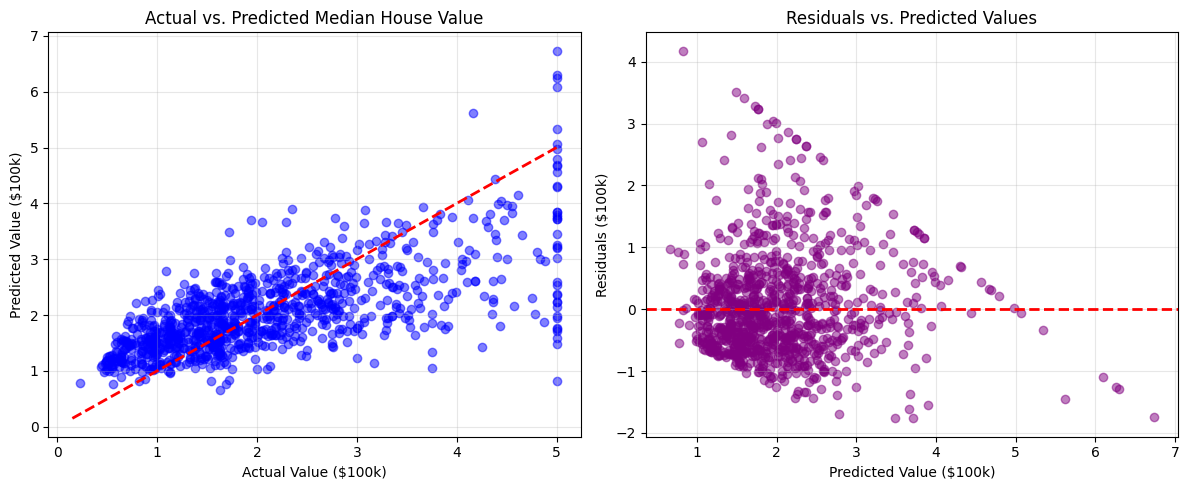

In [6]:
# 1. Actual vs Predicted Scatter Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Sample 1000 points from test set
np.random.seed(42)
sample_indices = np.random.choice(len(y_test), size=1000, replace=False)

plt.scatter(y_test.iloc[sample_indices], y_pred_simple[sample_indices], alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Median House Value')
plt.xlabel('Actual Value ($100k)')
plt.ylabel('Predicted Value ($100k)')
plt.grid(True, alpha=0.3)

# 2. Residuals Plot
plt.subplot(1, 2, 2)
residuals_simple = y_test - y_pred_simple
plt.scatter(y_pred_simple[sample_indices], residuals_simple.iloc[sample_indices], alpha=0.5, color='purple')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Value ($100k)')
plt.ylabel('Residuals ($100k)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6. Multiple Linear Regression (All Features)
Now let's build a Multiple Linear Regression model using all 8 features in the dataset, and see how much the accuracy improves.

In [7]:
# Select all features and split
X_multi = df.drop(columns=['MedHouseVal'])
X_train_multi, X_test_multi, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Train the model
multi_model = LinearRegression()
multi_model.fit(X_train_multi, y_train_m)

# Output coefficients
print("Multiple Linear Regression Coefficients:")
features = X_multi.columns
for feat, coef in zip(features, multi_model.coef_):
    print(f"{feat}: {coef:.4f}")
print(f"Intercept: {multi_model.intercept_:.4f}")

Multiple Linear Regression Coefficients:
MedInc: 0.4487
HouseAge: 0.0097
AveRooms: -0.1233
AveBedrms: 0.7831
Population: -0.0000
AveOccup: -0.0035
Latitude: -0.4198
Longitude: -0.4337
Intercept: -37.0233


### 7. Evaluation & Comparison of Simple vs. Multiple Linear Regression
We will predict target values using the multiple regression model and compare the performance metrics side-by-side.

In [8]:
# Predictions
y_pred_multi = multi_model.predict(X_test_multi)

# Calculate metrics
mae_multi = mean_absolute_error(y_test, y_pred_multi)
mse_multi = mean_squared_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test, y_pred_multi)

# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Simple Linear Regression (MedInc only)': [
        f"{mae_simple:.4f} (~${mae_simple * 100000:,.2f})",
        f"{mse_simple:.4f}",
        f"{rmse_simple:.4f} (~${rmse_simple * 100000:,.2f})",
        f"{r2_simple:.4f}"
    ],
    'Multiple Linear Regression (All Features)': [
        f"{mae_multi:.4f} (~${mae_multi * 100000:,.2f})",
        f"{mse_multi:.4f}",
        f"{rmse_multi:.4f} (~${rmse_multi * 100000:,.2f})",
        f"{r2_multi:.4f}"
    ]
})

print("Model Comparison Summary:")
comparison_df

Model Comparison Summary:


,Metric,Simple Linear Regression (MedInc only),Multiple Linear Regression (All Features)
0,MAE,"0.6299 (~$62,990.87)","0.5332 (~$53,320.01)"
1,MSE,0.7091,0.5559
2,RMSE,"0.8421 (~$84,209.01)","0.7456 (~$74,558.14)"
3,R2 Score,0.4589,0.5758


---

## Sigmoid Function

The Sigmoid function maps any input value to a probability between 0 and 1.

Formula:
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

In [9]:
import numpy as np

# Define the sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Test values
print("sigmoid(-5) =", sigmoid(-5))
print("sigmoid(0)  =", sigmoid(0))
print("sigmoid(5)  =", sigmoid(5))

sigmoid(-5) = 0.0066928509242848554
sigmoid(0)  = 0.5
sigmoid(5)  = 0.9933071490757153


## Prediction using Student Data

In [10]:
df = pd.read_csv('Dataset/student_data.csv')
df.head()

,Student,Hours_Studied,Pass
0,A,1,0
1,B,2,0
2,C,3,0
3,D,4,0
4,E,5,1


In [11]:
x = df[['Hours_Studied']]
y=df['Pass']

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [13]:
# Initialize and train the Logistic Regression model
model = LogisticRegression()
model.fit(x_train, y_train)

# Make predictions on the test set
y_pred = model.predict(x_test)
print("Predicted:", y_pred)
print("Actual:   ", y_test.values)

# Predict for a student studying 6 hours
new_data = pd.DataFrame({'Hours_Studied': [6]})
print("Prediction for 6 hours:", model.predict(new_data))

Predicted: [1 0]
Actual:    [1 0]
Prediction for 6 hours: [1]
